Loading dataset:

In [1]:
import pandas as pd
dataset = pd.read_csv("insurance_pre.csv")
dataset.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


Data Preprocessing:

In [2]:
dataset=pd.get_dummies(dataset,drop_first=True)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


In [3]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [4]:
independent=dataset[['age','bmi','children','sex_male','smoker_yes']]
dependent=dataset[['charges']]

Train-Test Split:

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(independent,dependent,test_size=0.3,random_state=0)

AdaBoostRegressor :

In [6]:
from sklearn.ensemble import AdaBoostRegressor
ada_model = AdaBoostRegressor(n_estimators=100,learning_rate=0.1,random_state=0)
ada_model.fit(x_train,y_train.values.ravel())
y_predict_ada=ada_model.predict(x_test)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ada = mean_absolute_error(y_test,y_predict_ada)
mse_ada = mean_squared_error(y_test,y_predict_ada)
rmse_ada= np.sqrt(mse_ada)
r2_ada  = r2_score(y_test,y_predict_ada)

print("AdaBoost")
print("MAE:",mae_ada)
print("MSE:",mse_ada)
print("RSME:",rmse_ada)
print("R2:",r2_ada)

AdaBoost
MAE: 3953.615809107227
MSE: 22203548.702271286
RSME: 4712.064165763374
R2: 0.8607661429916281


GradientBoostingRegressor :

In [8]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=0
)

gb_model.fit(x_train, y_train.values.ravel())

y_predict_gb = gb_model.predict(x_test)

In [9]:
mae_gb = mean_absolute_error(y_test, y_predict_gb)
mse_gb = mean_squared_error(y_test, y_predict_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_predict_gb)

print("Gradient Boosting")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)

Gradient Boosting
MAE : 2475.75567605958
MSE : 17330078.374980524
RMSE: 4162.94107272497
R2  : 0.8913266664369246


XGBoost Regressor :

In [10]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [11]:
import xgboost

print(xgboost.__version__)

1.6.2


In [12]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=0
)

xgb_model.fit(x_train, y_train)

y_predict_xgb = xgb_model.predict(x_test)

In [13]:
mae_xgb = mean_absolute_error(y_test, y_predict_xgb)
mse_xgb = mean_squared_error(y_test, y_predict_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_predict_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2 :", r2_xgb)

XGBoost
MAE : 2396.541433799013
MSE : 17021052.51388461
RMSE: 4125.657828017807
R2 : 0.8932645036328012


LightGBM Regressor:

In [14]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [15]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=0,
    verbose=-1
)

lgb_model.fit(x_train, y_train)

y_predict_lgb = lgb_model.predict(x_test)

C:\Users\HP\Anaconda3\lib\site-packages\dask\dataframe\utils.py:14: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm
C:\Users\HP\Anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py:152: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  "following reason:\n" + str(exception) + "\n"
  File "C:\Users\HP\Anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py", line 229, in _count_physical_cores
    capture_output=True)
  File "C:\Users\HP\Anaconda3\lib\subprocess.py", line 488, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\HP\Anaconda3\lib\subprocess.py", line 800, in __init__
    restore_signals, start_

In [16]:
mae_lgb = mean_absolute_error(y_test, y_predict_lgb)
mse_lgb = mean_squared_error(y_test, y_predict_lgb)
rmse_lgb = np.sqrt(mse_lgb)
r2_lgb = r2_score(y_test, y_predict_lgb)

print("LightGBM")
print("MAE :", mae_lgb)
print("MSE :", mse_lgb)
print("RMSE:", rmse_lgb)
print("R2  :", r2_lgb)

LightGBM
MAE : 2430.301017274049
MSE : 16977829.330791906
RMSE: 4120.416159903258
R2  : 0.8935355472652796


Comparison using dataframe:

In [17]:
comparison = pd.DataFrame({
    'Model': ['AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM'],
    'MAE': [mae_ada, mae_gb, mae_xgb, mae_lgb],
    'MSE': [mse_ada, mse_gb, mse_xgb, mse_lgb],
    'RMSE': [rmse_ada, rmse_gb, rmse_xgb, rmse_lgb],
    'R2': [r2_ada, r2_gb, r2_xgb, r2_lgb]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,AdaBoost,3953.615809,2.220355e+07,4712.064166,0.860766
1,Gradient Boosting,2475.755676,1.733008e+07,4162.941073,0.891327
2,XGBoost,2396.541434,1.702105e+07,4125.657828,0.893265
3,LightGBM,2430.301017,1.697783e+07,4120.416160,0.893536


R2 Comparison:

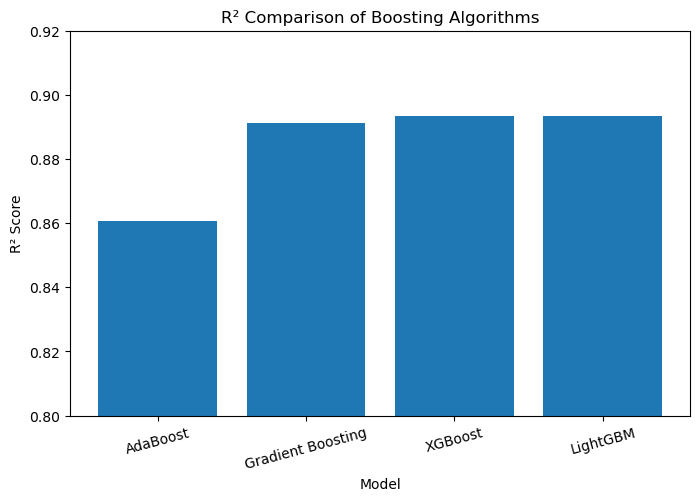

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['R2'])

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('R² Comparison of Boosting Algorithms')

plt.ylim(0.8, 0.92)
plt.xticks(rotation=15)

plt.show()

Feature Importance :

In [19]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker_yes,0.856313
1,bmi,0.084047
0,age,0.047572
2,children,0.010492
3,sex_male,0.001575


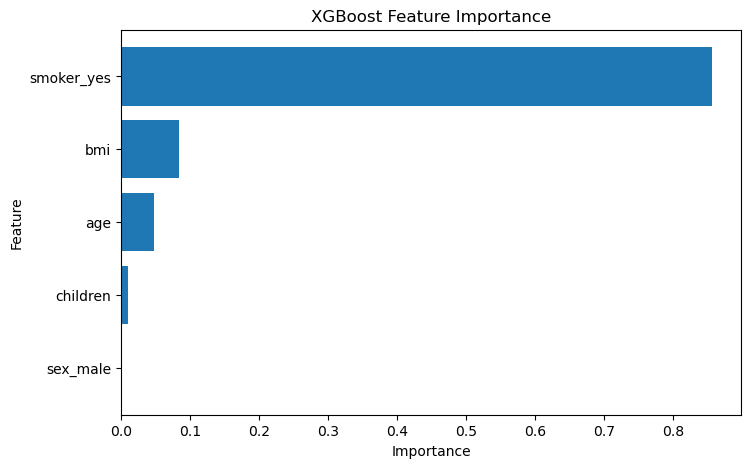

In [20]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')

plt.gca().invert_yaxis()

plt.show()

Model Prediction Vs actual insurance charges:

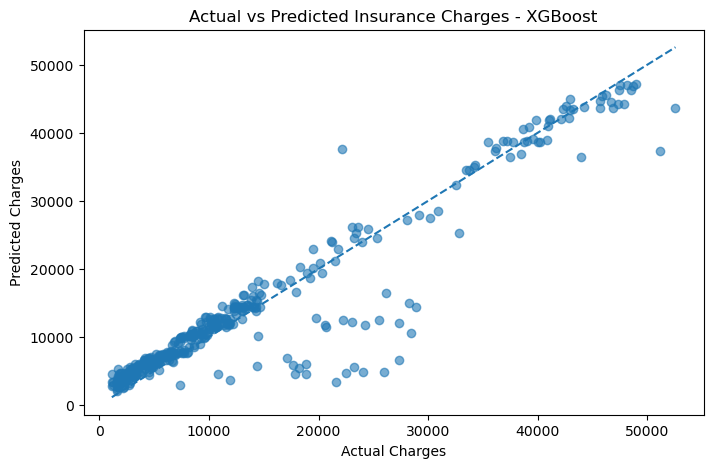

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_predict_xgb, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges - XGBoost")

plt.show()

### Conclusion
Four boosting algorithms were implemented for predicting insurance charges: AdaBoost, Gradient Boosting, XGBoost, and LightGBM.

Among the models tested, the gradient-boosting-based models achieved higher R² scores and lower prediction errors than AdaBoost on the selected test set. XGBoost achieved the lowest MAE, while LightGBM achieved the lowest RMSE and highest R² in this experiment.

The XGBoost feature-importance analysis showed that smoker_yes was the most influential feature for the model, followed by features such as BMI and age.

The Actual vs Predicted plot showed that many predictions were close to the ideal prediction line, while some observations had larger prediction errors.

Note: The comparison is based on a single train-test split (random_state=0), so the results describe this particular experiment and are not a universal ranking of the algorithms.